## Import the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import matplotlib.dates as mdates
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import jarque_bera

## Load the Data

### SP500 Data

In [2]:
sp500 = pd.read_csv("data/sp500.csv")

In [3]:
sp500.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
1,Date,NaN,NaN,NaN,NaN,NaN
2,1950-01-03,16.65999984741211,16.65999984741211,16.65999984741211,16.65999984741211,1260000
3,1950-01-04,16.850000381469727,16.850000381469727,16.850000381469727,16.850000381469727,1890000
4,1950-01-05,16.93000030517578,16.93000030517578,16.93000030517578,16.93000030517578,2550000


In [4]:
## The dataset was downloaded from yahoo.com thus, need to import with skiprows=2; to match the actual format 

In [5]:
sp500 = pd.read_csv("data/sp500.csv", skiprows=2)

In [6]:
sp500.head()

,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,1950-01-03,16.66,16.66,16.66,16.66,1260000
1,1950-01-04,16.85,16.85,16.85,16.85,1890000
2,1950-01-05,16.93,16.93,16.93,16.93,2550000
3,1950-01-06,16.98,16.98,16.98,16.98,2010000
4,1950-01-09,17.08,17.08,17.08,17.08,2520000


In [7]:
sp500.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

In [8]:
sp500.head()

,Date,Close,High,Low,Open,Volume
0,1950-01-03,16.66,16.66,16.66,16.66,1260000
1,1950-01-04,16.85,16.85,16.85,16.85,1890000
2,1950-01-05,16.93,16.93,16.93,16.93,2550000
3,1950-01-06,16.98,16.98,16.98,16.98,2010000
4,1950-01-09,17.08,17.08,17.08,17.08,2520000


In [9]:
# Convert date column DataType to Date and then
# Setting it to index

sp500["Date"] = pd.to_datetime(sp500["Date"])
sp500.set_index("Date", inplace=True)

In [10]:
# Converting all the variables to numeric 
sp500 = sp500.apply(pd.to_numeric, errors="coerce")

In [11]:
sp500.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 19156 entries, 1950-01-03 to 2026-02-23
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   19156 non-null  float64
 1   High    19156 non-null  float64
 2   Low     19156 non-null  float64
 3   Open    19156 non-null  float64
 4   Volume  19156 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 897.9 KB


In [12]:
sp500.describe()

,Close,High,Low,Open,Volume
count,19156.000000,19156.000000,19156.000000,19156.000000,1.915600e+04
mean,927.305390,932.463628,921.424671,927.119601,1.246108e+09
std,1335.917369,1342.665268,1328.179009,1335.718220,1.817752e+09
min,16.660000,16.660000,16.660000,16.660000,0.000000e+00
25%,89.637499,90.389999,88.900002,89.627499,1.072750e+07
50%,274.375000,276.015015,272.865005,274.365005,1.488950e+08
75%,1271.815033,1279.312531,1262.929993,1271.535004,2.530452e+09
max,6978.600098,7002.279785,6963.459961,7002.000000,1.145623e+10


In [13]:
# Checking for any null-data present
sp500.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

---

### Nifty50  Data

In [14]:
nifty50 = pd.read_csv('data/nifty50.csv', skiprows=2)

In [15]:
nifty50.head()

,Date,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
1,2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2,2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
3,2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
4,2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0


In [16]:
nifty50.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

In [17]:
# Convert date column DataType to Date and then
# Setting it to index

nifty50["Date"] = pd.to_datetime(nifty50["Date"])
nifty50.set_index("Date", inplace=True)

In [18]:
# Converting all the variables to numeric 

nifty50 = nifty50.apply(pd.to_numeric, errors="coerce")

In [19]:
nifty50.head()

,Close,High,Low,Open,Volume
Date,,,,,
2007-09-17,4494.649902,4549.049805,4482.850098,4518.450195,0
2007-09-18,4546.200195,4551.799805,4481.549805,4494.100098,0
2007-09-19,4732.350098,4739.000000,4550.250000,4550.250000,0
2007-09-20,4747.549805,4760.850098,4721.149902,4734.850098,0
2007-09-21,4837.549805,4855.700195,4733.700195,4752.950195,0


----

### Currency Data

In [20]:
usd_inr = pd.read_csv('data/USDINR_daily_clean.csv', skiprows=2)

In [21]:
usd_inr.head()

,Date,Unnamed: 1,Unnamed: 2
0,2007-01-02,44.122002,-0.002106
1,2007-01-03,44.111000,-0.000249
2,2007-01-04,44.095001,-0.000363
3,2007-01-05,44.139999,0.001020
4,2007-01-08,44.255001,0.002602


In [22]:
usd_inr.columns = ["Date", "Close", "Log Return"]

In [23]:
usd_inr.head()

,Date,Close,Log Return
0,2007-01-02,44.122002,-0.002106
1,2007-01-03,44.111000,-0.000249
2,2007-01-04,44.095001,-0.000363
3,2007-01-05,44.139999,0.001020
4,2007-01-08,44.255001,0.002602


In [24]:
usd_inr = usd_inr[["Date", "Close"]]
usd_inr = usd_inr.dropna()

In [25]:
# Convert date column DataType to Date and then
# Setting it to index

usd_inr["Date"] = pd.to_datetime(usd_inr["Date"])
usd_inr.set_index("Date", inplace=True)

In [26]:
usd_inr.head()

,Close
Date,
2007-01-02,44.122002
2007-01-03,44.111000
2007-01-04,44.095001
2007-01-05,44.139999
2007-01-08,44.255001


## Merge the Data

### Keep only 'close' column

In [27]:
sp500 = sp500[["Close"]]
nifty50 = nifty50[["Close"]]
usd_inr.columns = ["USDINR"]

sp500.columns = ["SP500"]
nifty50.columns = ["NIFTY"]

### Align all the Data for Date starting from 

In [28]:
data = sp500.join(nifty50, how="inner")
data = data.join(usd_inr, how="inner")
data = data.dropna()

In [29]:
data.head()
data.index.min()
data.index.max()
data.isna().sum()

SP500     0
NIFTY     0
USDINR    0
dtype: int64

In [30]:
data.head()

,SP500,NIFTY,USDINR
Date,,,
2007-09-17,1476.650024,4494.649902,40.376999
2007-09-18,1519.780029,4546.200195,40.216999
2007-09-19,1529.030029,4732.350098,40.033001
2007-09-20,1518.750000,4747.549805,39.615002
2007-09-21,1525.750000,4837.549805,39.770000


In [31]:
# Here, all three column are currency form, but log values are preffered for the VAR model

In [32]:
returns = np.log(data / data.shift(1))
returns = returns.dropna()

In [33]:
returns.head()

,SP500,NIFTY,USDINR
Date,,,
2007-09-18,0.028790,0.011404,-0.003971
2007-09-19,0.006068,0.040130,-0.004586
2007-09-20,-0.006746,0.003207,-0.010496
2007-09-21,0.004598,0.018780,0.003905
2007-09-24,-0.005270,0.019377,-0.008561


# Phase 1 –

## Method-1

In [34]:
returns.describe()

,SP500,NIFTY,USDINR
count,4371.000000,4371.000000,4371.000000
mean,0.000352,0.000399,0.000186
std,0.012865,0.013259,0.005101
min,-0.127652,-0.152303,-0.060972
25%,-0.004442,-0.005277,-0.002147
50%,0.000740,0.000659,0.000022
75%,0.006032,0.006611,0.002400
max,0.109572,0.163343,0.060972


#### Check & Handle Missing Values

In [35]:
# Check for missing values
print("Missing Values")
print("-" * 30)
print(returns.isnull().sum())
print(f"\nTotal rows before cleaning: {len(returns)}")

# Drop NaN rows (first row from log diff, and any market holiday mismatches)
returns = returns.dropna()

print(f"Total rows after cleaning: {len(returns)}")
print(f"\nDate range: {returns.index.min()} to {returns.index.max()}")

Missing Values
------------------------------
SP500     0
NIFTY     0
USDINR    0
dtype: int64

Total rows before cleaning: 4371
Total rows after cleaning: 4371

Date range: 2007-09-18 00:00:00 to 2026-02-23 00:00:00


### Plot the Series

In [36]:
# We are marking 2008-2009 period as it showcase the Global Financial Crisis hitting both markets
# and 2020/02-2025/05 period to showcase COVID crash

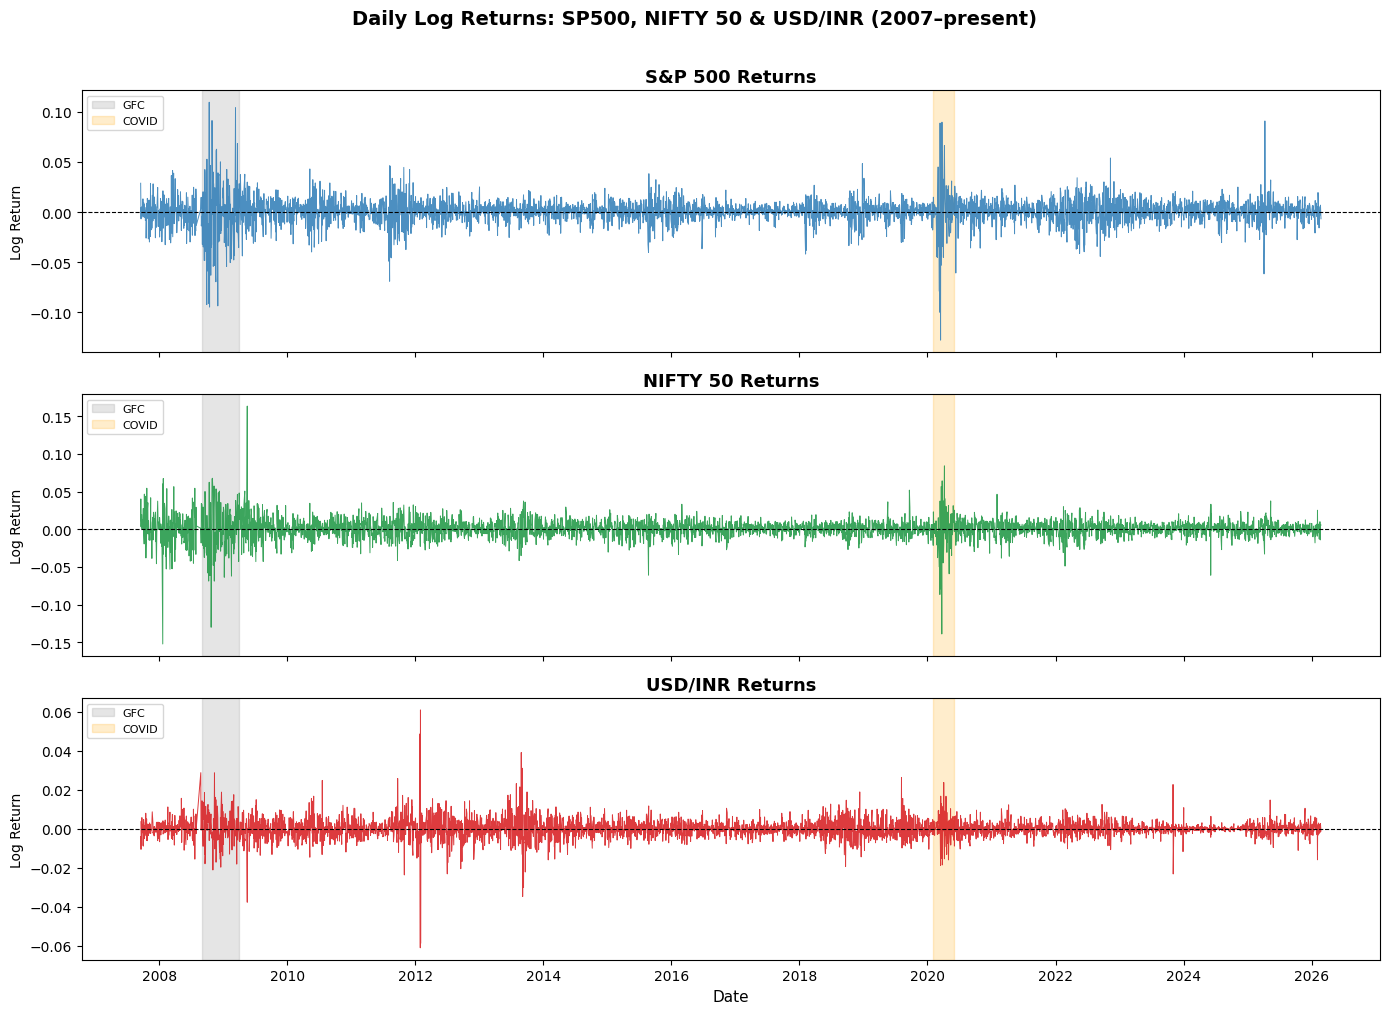

In [37]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

series_info = [
    ("SP500",  "#2c7bb6", "S&P 500 Returns"),
    ("NIFTY",  "#1a9641", "NIFTY 50 Returns"),
    ("USDINR", "#d7191c", "USD/INR Returns"),
]

for ax, (col, color, title) in zip(axes, series_info):
    ax.plot(returns.index, returns[col], color=color, linewidth=0.7, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel("Log Return", fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

    # Shade key crisis periods
    ax.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-03-31"),
               color='gray', alpha=0.2, label="GFC")
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-31"),
               color='orange', alpha=0.2, label="COVID")
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel("Date", fontsize=11)
plt.suptitle("Daily Log Returns: SP500, NIFTY 50 & USD/INR (2007–present)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("returns_plot.png", dpi=150, bbox_inches='tight')
plt.show()

The clustering we see visually — calm periods, then wild periods — proves variance changes over time. This is called heteroskedasticity in formal terms. \
During normal times, SP500 moves ±0.5% daily. During 2008 crisis, it moved ±5% daily. That changing spread is heteroskedasticity.

**Observations:** \
Returns are approximately stationary \
They oscillate around zero with no permanent upward/downward drift — unlike prices which trend upward forever. This means returns are suitable for statistical modeling.

### Data Distribution

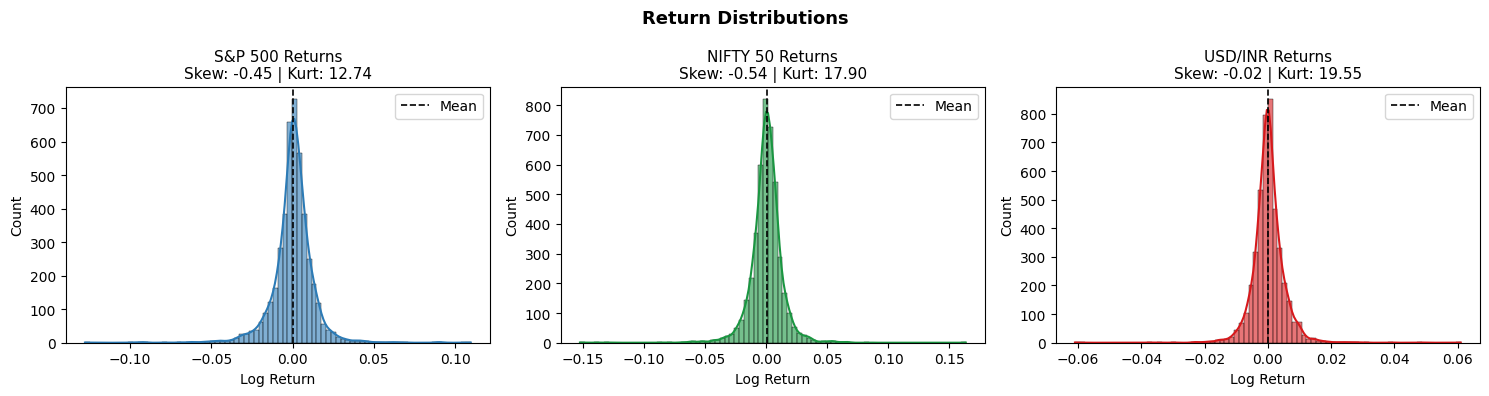

In [38]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (col, color, title) in zip(axes, series_info):
    sns.histplot(returns[col], bins=80, kde=True, color=color, ax=ax, alpha=0.6)
    ax.axvline(returns[col].mean(), color='black', linestyle='--', linewidth=1.2, label='Mean')
    ax.set_title(f"{title}\nSkew: {returns[col].skew():.2f} | Kurt: {returns[col].kurt():.2f}",
                 fontsize=11)
    ax.set_xlabel("Log Return")
    ax.legend()

plt.suptitle("Return Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("return_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

**Skewness** → Losses hit harder and faster than gains recover \
**Kurtosis** → Extreme events (crashes) happen way more often than "normal" math assumes

SP500 returns exhibit kurtosis of 12.74, indicating fat tails and suggesting that extreme return events occur far more frequently than a normal distribution would predict. This violates the normality assumption and motivates the use of GARCH modeling with a Student's t-distribution.

**Observations:** \
High kurtosis + negative skew formally breaks the normality assumption. \
This is a critical finding because almost every basic model (OLS, simple ARIMA) assumes normality. \
This shows that assumption is wrong for the data.

## Method-2

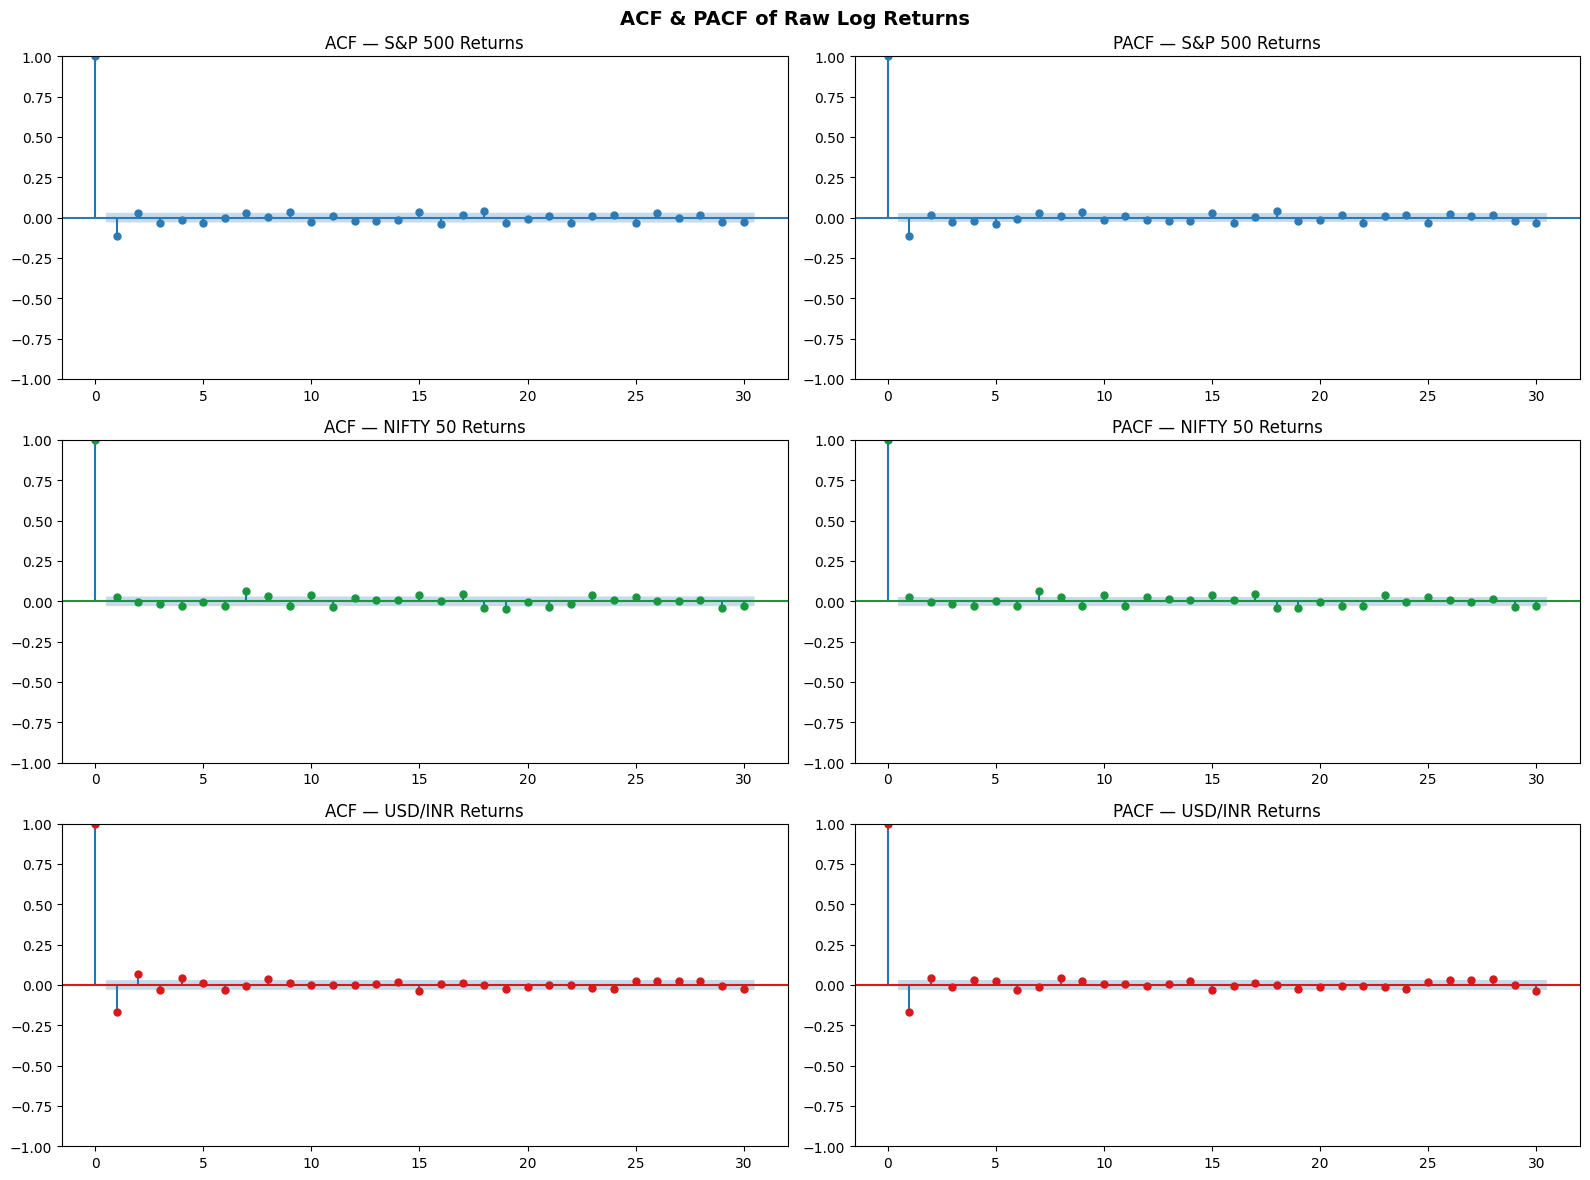

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

series_info = [
    ("SP500",  "#2c7bb6", "S&P 500"),
    ("NIFTY",  "#1a9641", "NIFTY 50"),
    ("USDINR", "#d7191c", "USD/INR"),
]

for i, (col, color, title) in enumerate(series_info):
    plot_acf(returns[col], lags=30, ax=axes[i, 0],
             color=color, title=f"ACF — {title} Returns")
    plot_pacf(returns[col], lags=30, ax=axes[i, 1],
              color=color, title=f"PACF — {title} Returns")

plt.suptitle("ACF & PACF of Raw Log Returns", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("acf_pacf_returns.png", dpi=150, bbox_inches='tight')
plt.show()

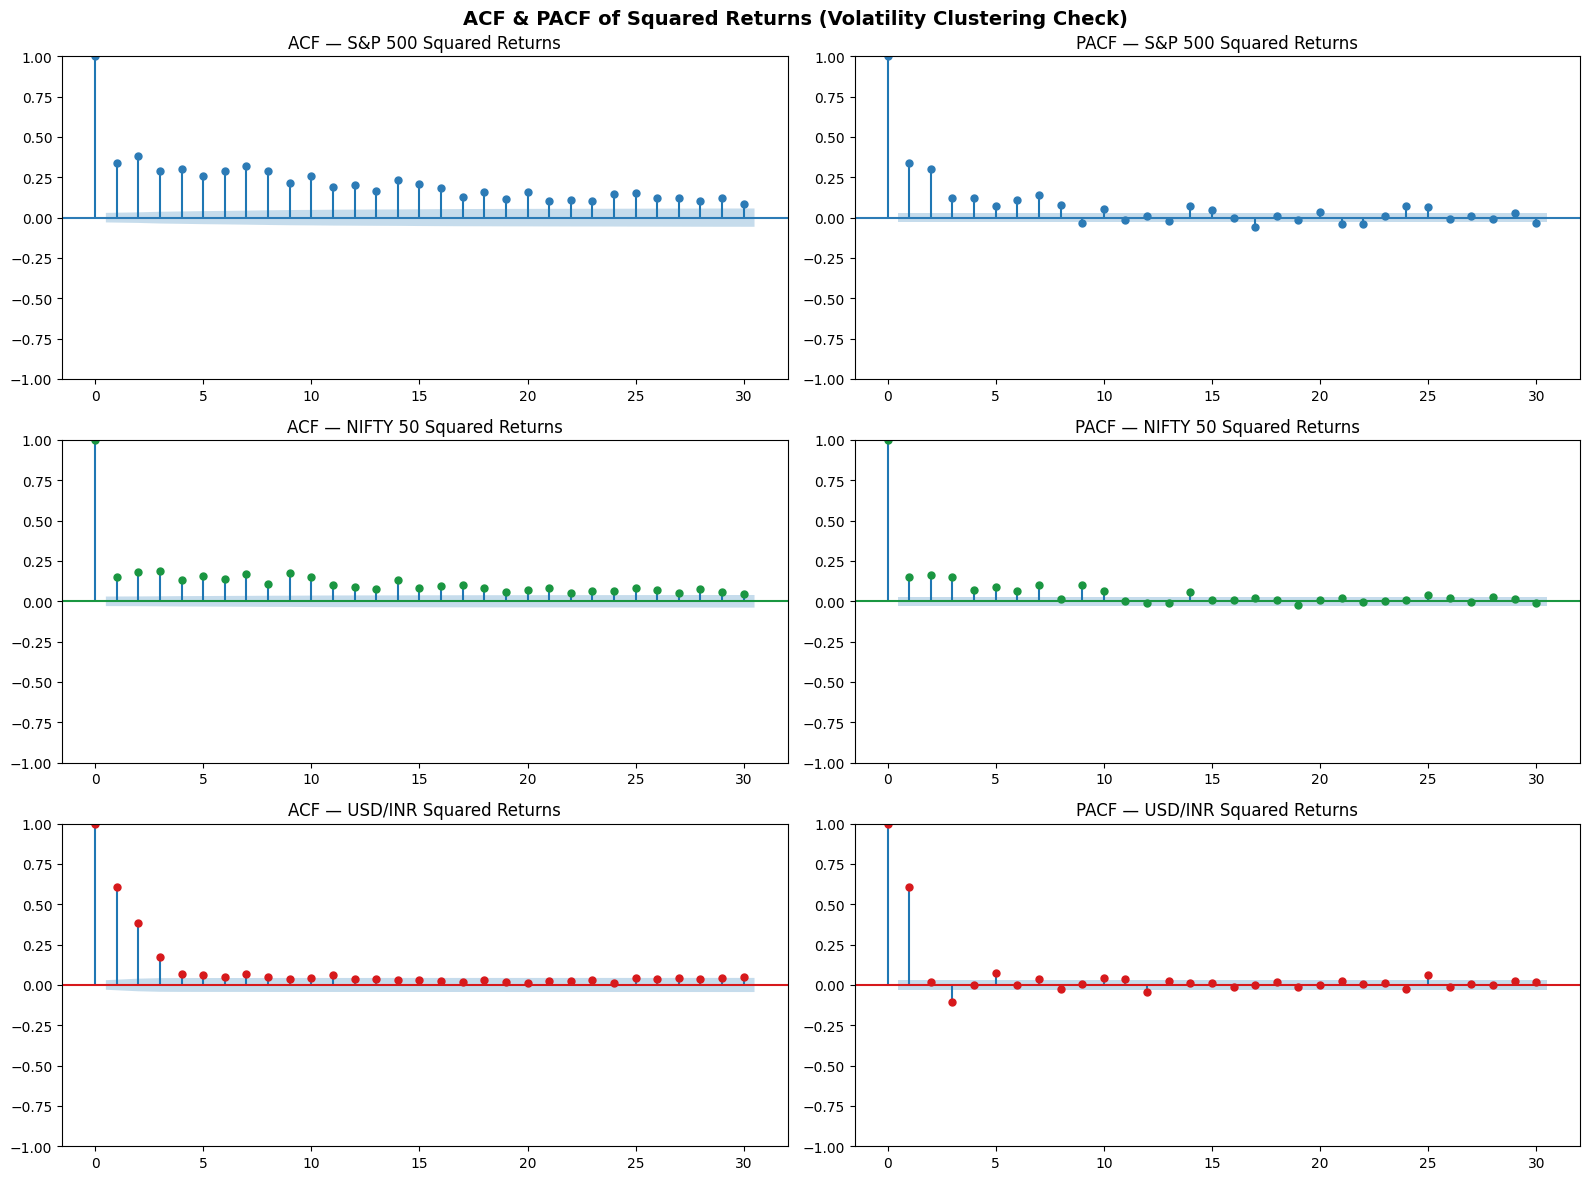

In [40]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i, (col, color, title) in enumerate(series_info):
    squared = returns[col] ** 2          # ← the key difference

    plot_acf(squared, lags=30, ax=axes[i, 0],
             color=color, title=f"ACF — {title} Squared Returns")
    plot_pacf(squared, lags=30, ax=axes[i, 1],
              color=color, title=f"PACF — {title} Squared Returns")

plt.suptitle("ACF & PACF of Squared Returns (Volatility Clustering Check)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("acf_pacf_squared.png", dpi=150, bbox_inches='tight')
plt.show()

- Equity markets (SP500, NIFTY) react to news instantly and noisily — volatility spikes and dissipates quickly because millions of traders are constantly correcting prices.
- Currency markets (USD/INR) are heavily influenced by RBI interventions, trade flows, and macro policy — these forces are slow-moving, so once volatility enters the exchange rate, it persists for days before settling down.

ACF and PACF analysis of squared returns reveals heteroskedastic structure across all three series. \
Notably, USD/INR squared returns exhibit exponential decay in the ACF with only the first lag significant in the PACF — a classic AR(1) variance signature consistent with a GARCH(1,1) process. \
This suggests exchange rate volatility is highly persistent, likely reflecting the slow-moving nature of macro and policy driven currency pressures compared to equity markets.

In [41]:
from statsmodels.stats.diagnostic import het_arch

print("=" * 55)
print("ARCH LM Test — Testing for Heteroskedasticity")
print("=" * 55)
print("H0: No ARCH effects (variance is constant)")
print("H1: ARCH effects present (variance is changing)")
print("=" * 55)

for col, _, title in series_info:
    lm_stat, lm_pval, f_stat, f_pval = het_arch(returns[col], nlags=5)
    conclusion = "ARCH effects PRESENT → GARCH needed" if lm_pval < 0.05 \
                 else "No ARCH effects found"
    print(f"\n{title}")
    print(f"  LM Statistic : {lm_stat:.4f}")
    print(f"  p-value      : {lm_pval:.6f}")
    print(f"  Conclusion   : {conclusion}")

ARCH LM Test — Testing for Heteroskedasticity
H0: No ARCH effects (variance is constant)
H1: ARCH effects present (variance is changing)

S&P 500
  LM Statistic : 970.6149
  p-value      : 0.000000
  Conclusion   : ARCH effects PRESENT → GARCH needed

NIFTY 50
  LM Statistic : 356.1317
  p-value      : 0.000000
  Conclusion   : ARCH effects PRESENT → GARCH needed

USD/INR
  LM Statistic : 1674.2615
  p-value      : 0.000000
  Conclusion   : ARCH effects PRESENT → GARCH needed


# Phase 2 — ADF & KPSS Stationarity Tests

#### What is a Unit Root?
A series has a unit root if shocks to it are permanent — it never returns to its original level.

### Test 1 — ADF (Augmented Dickey-Fuller)

##### $H_0$: Series HAS a unit root (non-stationary)
##### $H_1$: Series is stationary
##### p-value < 0.05 → reject H0 → series IS stationary

In [42]:
# ── ADF Test Function ──────────────────────────────────────────
def run_adf(series, name):
    result = adfuller(series, autolag='AIC')
    return {
        'Series'        : name,
        'ADF Statistic' : round(result[0], 4),
        'p-value'       : round(result[1], 6),
        'Lags Used'     : result[2],
        'Obs Used'      : result[3],
        'Critical 1%'   : round(result[4]['1%'], 4),
        'Critical 5%'   : round(result[4]['5%'], 4),
        'Critical 10%'  : round(result[4]['10%'], 4),
        'Stationary?'   : 'Yes' if result[1] < 0.05 else 'No'
    }

# ── Run on all three return series ────────────────────────────
adf_results = pd.DataFrame([
    run_adf(returns['SP500'],  'SP500 Returns'),
    run_adf(returns['NIFTY'],  'NIFTY Returns'),
    run_adf(returns['USDINR'], 'USDINR Returns'),
])

adf_results.set_index('Series', inplace=True)
print("=" * 65)
print("        ADF TEST RESULTS — LOG RETURNS")
print("=" * 65)
print("H0: Series has a unit root (non-stationary)")
print("H1: Series is stationary")
print("Reject H0 if p-value < 0.05")
print("=" * 65)
print(adf_results.to_string())

        ADF TEST RESULTS — LOG RETURNS
H0: Series has a unit root (non-stationary)
H1: Series is stationary
Reject H0 if p-value < 0.05
                ADF Statistic  p-value  Lags Used  Obs Used  Critical 1%  Critical 5%  Critical 10% Stationary?
Series                                                                                                         
SP500 Returns        -12.7660      0.0         29      4341      -3.4319      -2.8622       -2.5671         Yes
NIFTY Returns        -12.5102      0.0         29      4341      -3.4319      -2.8622       -2.5671         Yes
USDINR Returns       -21.0234      0.0          8      4362      -3.4319      -2.8622       -2.5671         Yes


#### Interpretation

1. **SP500 Returns — ADF: -12.766, p = 0.000** \
The ADF statistic of -12.766 far exceeds the 1% critical value of -3.432, and the p-value is effectively zero. We reject the null hypothesis of a unit root with overwhelming confidence. SP500 log returns are stationary.

2. **NIFTY Returns — ADF: -12.510, p = 0.000** \
Identical conclusion to SP500. The ADF statistic of -12.510 comfortably clears even the strictest 1% threshold. NIFTY log returns are stationary.

3. **USD/INR Returns — ADF: -21.023, p = 0.000** \
The strongest result of the three. An ADF statistic of -21.023 is exceptionally large in magnitude, suggesting virtually no persistence in exchange rate returns. USD/INR log returns are stationary.

#### Final Verdict
The Augmented Dickey-Fuller test was applied to all three log return series. Results presented in the above Table show that the ADF statistic for SP500 (−12.766), NIFTY (−12.510), and USD/INR (−21.023) all fall far below the 1% critical value of −3.432, with p-values of effectively zero in each case. \
The null hypothesis of a unit root is rejected for all three series at the 1% significance level, confirming that log returns are stationary. \
Notably, USD/INR required only 8 lags compared to 29 for the equity series, consistent with the simpler autocorrelation structure identified during ACF/PACF analysis in Phase 1.

### Test 2 — KPSS (Kwiatkowski–Phillips–Schmidt–Shin)

##### $H_0$: Series is Stationary
##### $H_1$: Series has a unit root
##### p-value < 0.05 → reject H0 → series is non-stationary

In [43]:
# ── KPSS Test Function ─────────────────────────────────────────
def run_kpss(series, name):
    result = kpss(series, regression='c', nlags='auto')
    return {
        'Series'          : name,
        'KPSS Statistic'  : round(result[0], 4),
        'p-value'         : round(result[1], 6),
        'Lags Used'       : result[2],
        'Critical 1%'     : round(result[3]['1%'], 4),
        'Critical 5%'     : round(result[3]['5%'], 4),
        'Critical 10%'    : round(result[3]['10%'], 4),
        'Stationary?'     : 'Yes' if result[1] > 0.05 else 'No'
    }

# ── Run on all three return series ────────────────────────────
kpss_results = pd.DataFrame([
    run_kpss(returns['SP500'],  'SP500 Returns'),
    run_kpss(returns['NIFTY'],  'NIFTY Returns'),
    run_kpss(returns['USDINR'], 'USDINR Returns'),
])

kpss_results.set_index('Series', inplace=True)
print("=" * 65)
print("        KPSS TEST RESULTS — LOG RETURNS")
print("=" * 65)
print("H0: Series IS stationary")
print("H1: Series has a unit root (non-stationary)")
print("Reject H0 if p-value < 0.05")
print("=" * 65)
print(kpss_results.to_string())

        KPSS TEST RESULTS — LOG RETURNS
H0: Series IS stationary
H1: Series has a unit root (non-stationary)
Reject H0 if p-value < 0.05
                KPSS Statistic  p-value  Lags Used  Critical 1%  Critical 5%  Critical 10% Stationary?
Series                                                                                                
SP500 Returns           0.2135      0.1         20        0.739        0.463         0.347         Yes
NIFTY Returns           0.0502      0.1         15        0.739        0.463         0.347         Yes
USDINR Returns          0.0612      0.1          7        0.739        0.463         0.347         Yes


/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_66892/1110016537.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')
/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_66892/1110016537.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')
/var/folders/9b/_420w89j6jb0s4_8bvd0kkdh0000gn/T/ipykernel_66892/1110016537.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')


To formally assess the stationarity properties of our return series, we applied two complementary unit root tests — the Augmented Dickey-Fuller (ADF) test and the KPSS test — whose null hypotheses are opposite in nature, providing a robust cross-check. \
ADF results show test statistics of −12.766, −12.510, and −21.023 for SP500, NIFTY, and USD/INR respectively, all far exceeding the 1% critical value of −3.432 with p-values of effectively zero. The null hypothesis of a unit root is rejected for all three series. \
KPSS results corroborate this finding — test statistics of 0.214, 0.050, and 0.061 all fall well below the 5% critical value of 0.463, with p-values exceeding 0.1 in all cases. The null hypothesis of stationarity cannot be rejected. \ 
Crucially, both tests agree across all three series, leaving no ambiguity. Log returns of SP500, NIFTY 50, and USD/INR are confirmed stationary — validating their use in subsequent VAR and GARCH modeling without risk of spurious regression.

----